**EDA INTRODUCTION **

Exploratory Data Analysis was conducted on the cleaned CFD dataset to understand the distribution, relationships, and physical behavior of the flow variables before normalization and model development. This step is essential to preserve the physical interpretation of the variables and to identify important flow characteristics such as velocity variation, pressure distribution, and nonlinear regions, including the wake behind the cylinder.

In [9]:
import pandas as pd

df_clean = pd.read_csv('/content/CFD_2D_cleaned.csv')

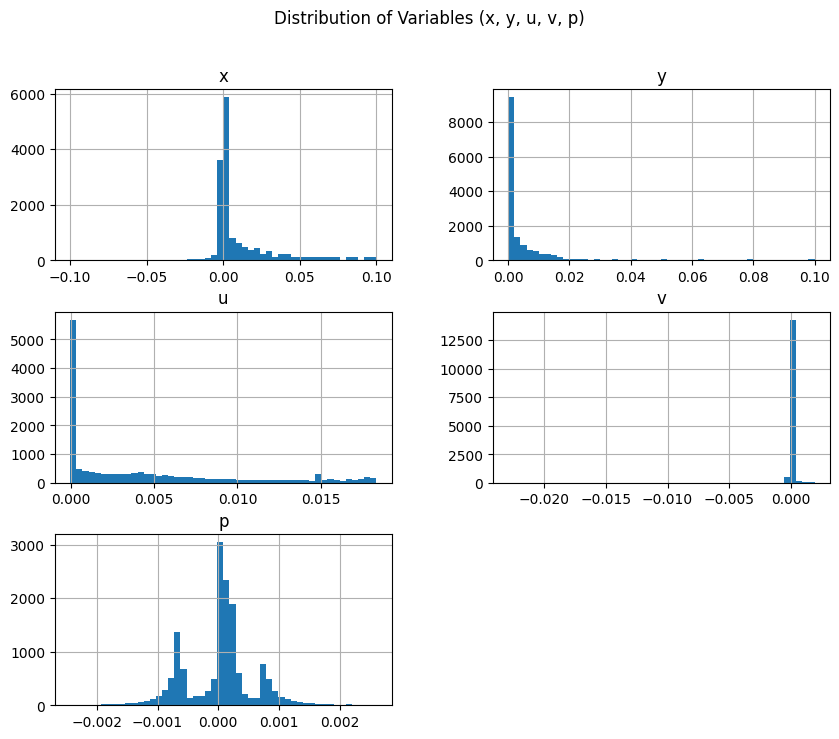

In [10]:
  ## DISTRIBUTION OF VARIABLES
  import matplotlib.pyplot as plt

# Plot distributions
df_clean.hist(figsize=(10, 8), bins=50)
plt.suptitle("Distribution of Variables (x, y, u, v, p)")
plt.show()

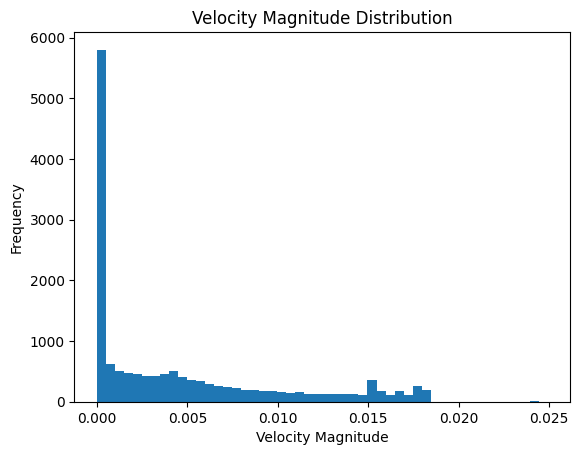

In [11]:
## VELOCITY MAGNITUDE ANALYSIS
import numpy as np

df_clean["velocity_magnitude"] = np.sqrt(df_clean["u"]**2 + df_clean["v"]**2)

plt.hist(df_clean["velocity_magnitude"], bins=50)
plt.title("Velocity Magnitude Distribution")
plt.xlabel("Velocity Magnitude")
plt.ylabel("Frequency")
plt.show()

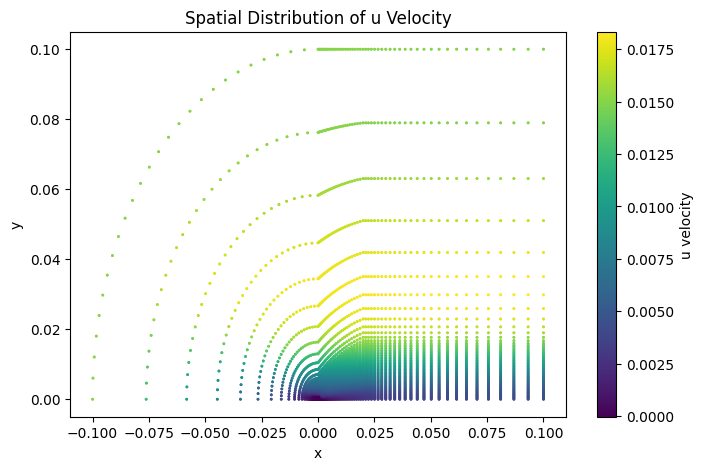

In [12]:
## SPATIAL VELOCITY FIELD
plt.figure(figsize=(8, 5))
plt.scatter(df_clean["x"], df_clean["y"], c=df_clean["u"], s=1)
plt.colorbar(label="u velocity")
plt.title("Spatial Distribution of u Velocity")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

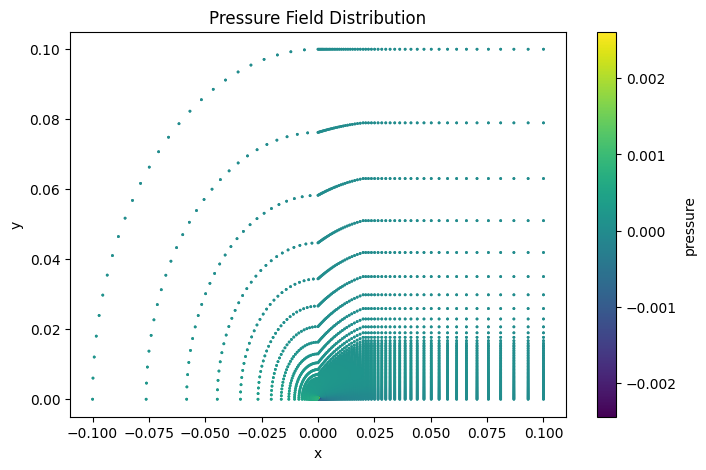

In [13]:
## PRESSURE FIELD ANALYSIS
plt.figure(figsize=(8, 5))
plt.scatter(df_clean["x"], df_clean["y"], c=df_clean["p"], s=1)
plt.colorbar(label="pressure")
plt.title("Pressure Field Distribution")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

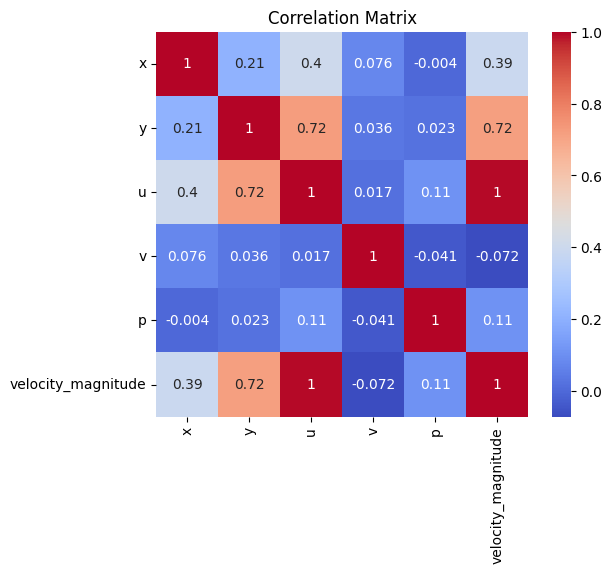

In [14]:
## CORRELATION ANALYSIS
import seaborn as sns

corr = df_clean.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

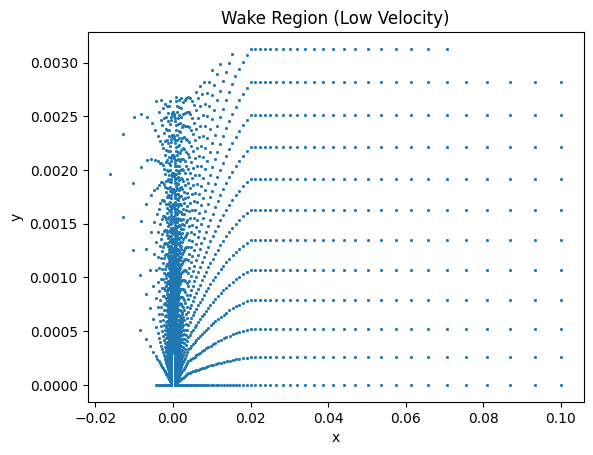

In [15]:
## IDENTIFY NONLINEAR REGIONS
# Highlight low velocity region (wake)
wake = df_clean[df_clean["velocity_magnitude"] < 0.005]

plt.scatter(wake["x"], wake["y"], s=1)
plt.title("Wake Region (Low Velocity)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

**EDA CONCLUSION **

The exploratory data analysis confirms that the dataset exhibits physically meaningful flow behavior consistent with two-dimensional cylinder flow. The velocity and pressure distributions reveal key features such as flow acceleration around the cylinder, pressure gradients, and the presence of a wake region downstream. The wake region is characterized by low velocity and strong nonlinear behavior, making it a critical area for evaluating model performance. Correlation analysis indicates meaningful relationships between spatial coordinates and flow variables, supporting the suitability of the dataset for machine learning. Overall, the dataset is well-structured, physically consistent, and appropriate for subsequent normalization and model development stages.